# exploratory data analysis with titanic dataset

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
train_data = pd.read_csv('train_titanic.csv')

In [167]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [168]:
train_data.shape

(891, 12)

In [169]:
train_data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [170]:
train_data.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [171]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [172]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [173]:
train_data.describe(include='O') # type: ignore

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


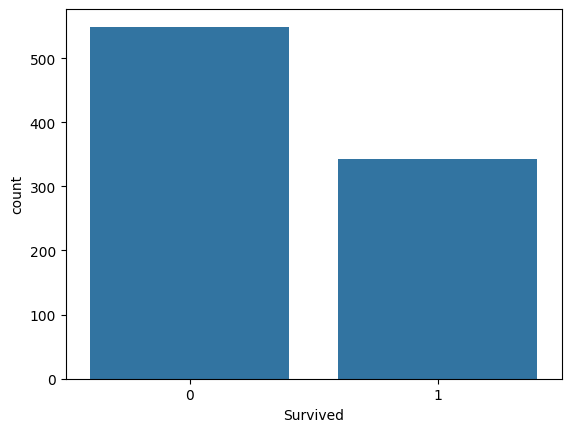

In [174]:
sns.countplot(x='Survived', data=train_data)
plt.show()

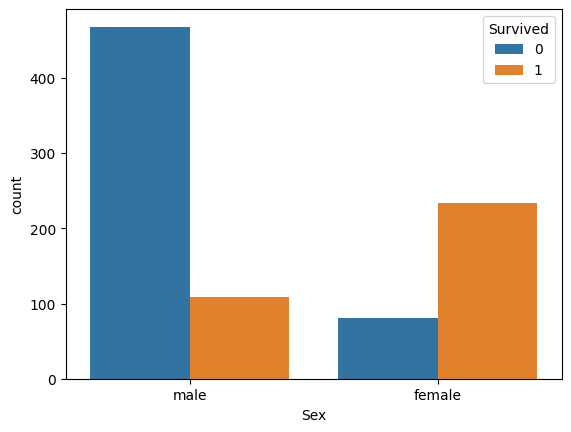

In [175]:
sns.countplot(x='Sex',hue='Survived', data=train_data)
plt.show()

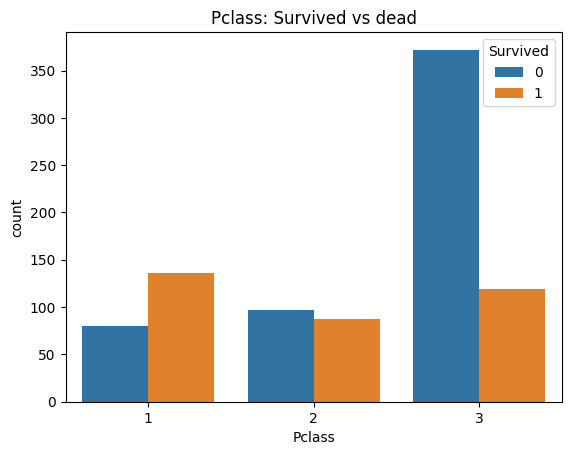

In [176]:
sns.countplot(x='Pclass',hue='Survived', data=train_data)
plt.title('Pclass: Survived vs dead')
plt.show()

In [177]:
pd.crosstab([train_data.Sex,train_data.Survived], train_data.Pclass,margins=True).style.background_gradient(cmap='summer')

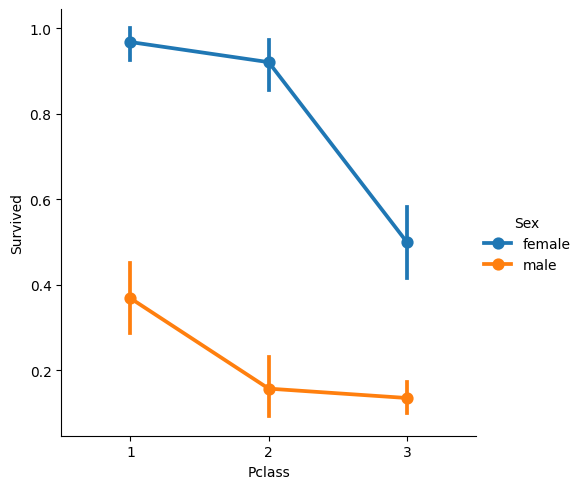

In [178]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=train_data, kind='point')
plt.show()

In [179]:
print('Oldest person survived was of:', train_data[train_data['Survived'] == 1]['Age'].max())
print('youngest person survived was of:', train_data[train_data['Survived'] == 1]['Age'].min())
print('average age of people survived was:', train_data[train_data['Survived'] == 1]['Age'].mean())

Oldest person survived was of: 80.0
youngest person survived was of: 0.42
average age of people survived was: 28.343689655172415


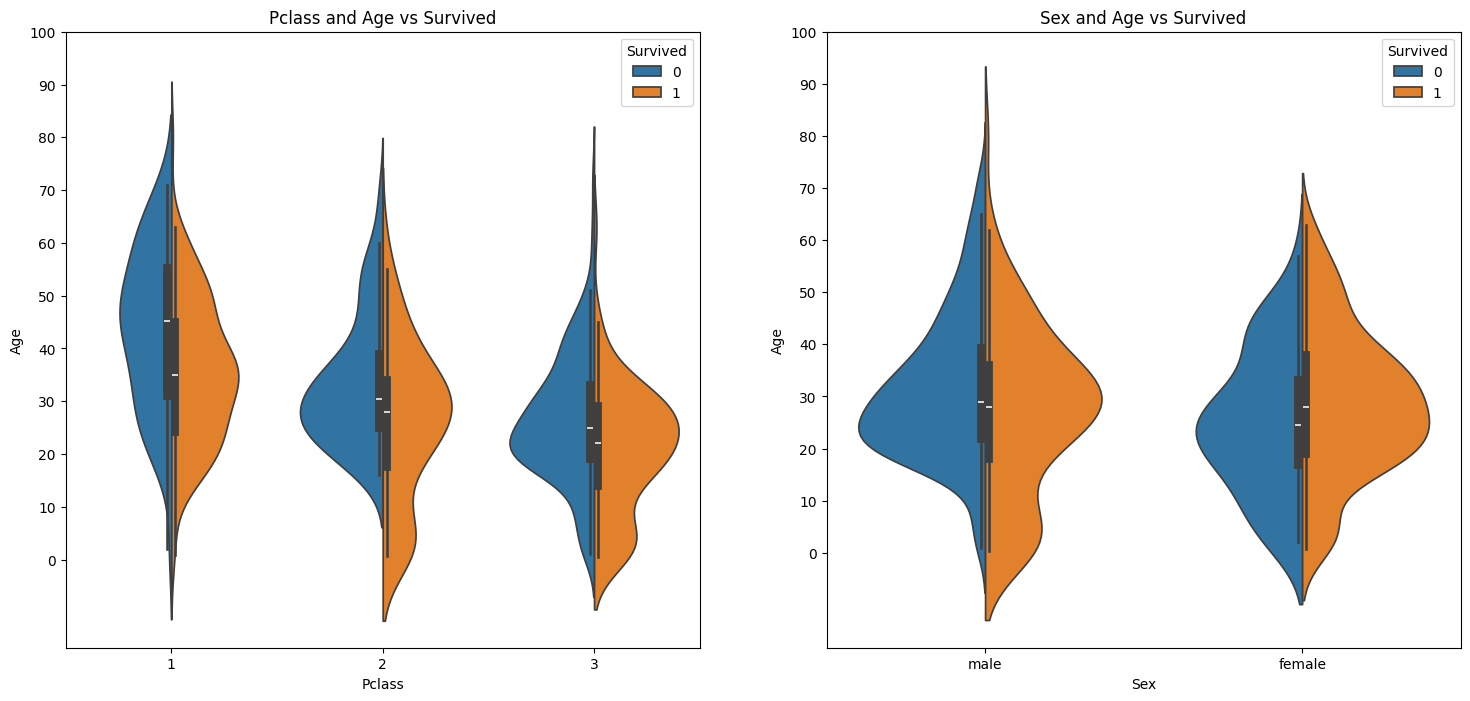

In [180]:
f, ax = plt.subplots(1,2, figsize=(18, 8))
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=train_data,split=True, ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0, 110, 10))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=train_data, split=True, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0, 110, 10))
plt.show()

In [181]:
train_data['Initial'] = 0
for i in train_data:
    train_data['Initial'] = train_data.Name.str.extract('([A-Za-z]+)\.')

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
C:\Users\gajen\AppData\Local\Temp\ipykernel_22940\3723320056.py:3: SyntaxWarning: invalid escape sequence '\.'
  train_data['Initial'] = train_data.Name.str.extract('([A-Za-z]+)\.')


In [182]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [183]:
pd.crosstab(train_data.Initial,train_data.Sex).T.style.background_gradient(cmap='summer')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [184]:
train_data['Initial'].replace(['Mlle', 'Mme', 'Ms', 'Dr', 'Major', 'Lady', 'Countess','Jonkheer', 'Col', 'Capt', 'Rev', 'Sir', 'Don'], ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)


C:\Users\gajen\AppData\Local\Temp\ipykernel_22940\1142391067.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Initial'].replace(['Mlle', 'Mme', 'Ms', 'Dr', 'Major', 'Lady', 'Countess','Jonkheer', 'Col', 'Capt', 'Rev', 'Sir', 'Don'], ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)


In [185]:
train_data.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.800725
Mrs       35.981818
Other     56.000000
Name: Age, dtype: float64

In [186]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Mr
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [187]:
train_data.loc[((train_data.Age.isnull())) & (train_data.Initial == 'Mr'), 'Age'] = 33
train_data.loc[((train_data.Age.isnull())) & (train_data.Initial == 'Mrs'), 'Age'] = 36
train_data.loc[((train_data.Age.isnull())) & (train_data.Initial == 'Master'), 'Age'] = 5
train_data.loc[((train_data.Age.isnull())) & (train_data.Initial == 'Miss'), 'Age'] = 22
train_data.loc[((train_data.Age.isnull())) & (train_data.Initial == 'Other'), 'Age'] = 46


In [188]:
train_data.Age.isnull().any()

np.False_

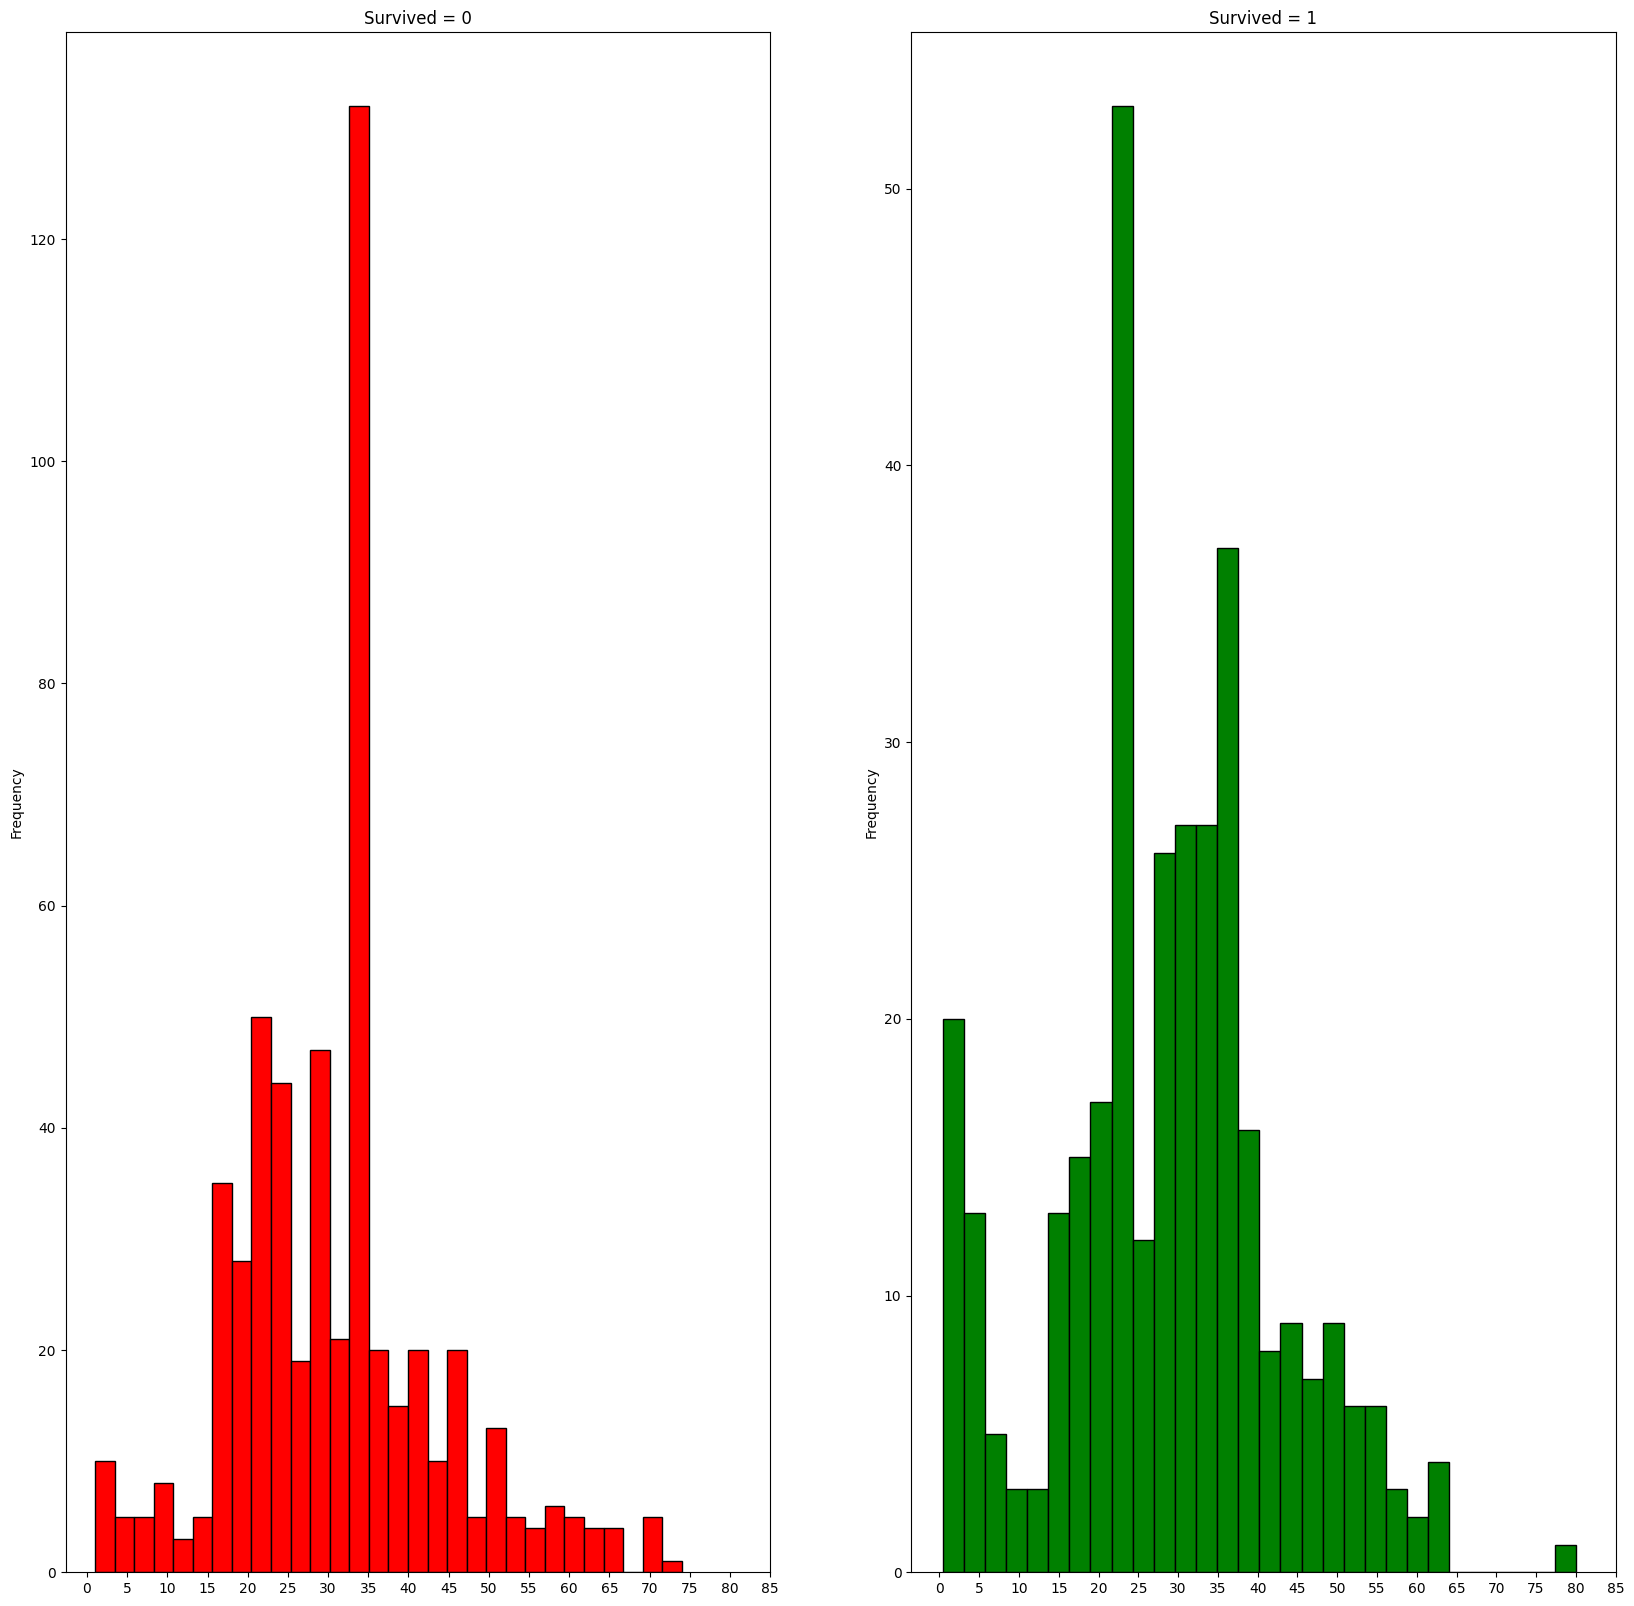

In [193]:
# import matplotlib.pyplot as plt
# import seaborn as sns
f,ax=plt.subplots(1,2,figsize=(20,20))
train_data[train_data['Survived']==0].Age.plot.hist(ax=ax[0], bins=30, edgecolor='black', color='red')
ax[0].set_title('Survived = 0')
x1 =list(range(0, 90, 5))
ax[0].set_xticks(x1)
train_data[train_data['Survived']==1].Age.plot.hist(ax=ax[1], bins=30, edgecolor='black', color='green')
x2= list(range(0, 90, 5))
ax[1].set_xticks(x2)
ax[1].set_title('Survived = 1')
plt.show()

<Figure size 2000x10000 with 0 Axes>

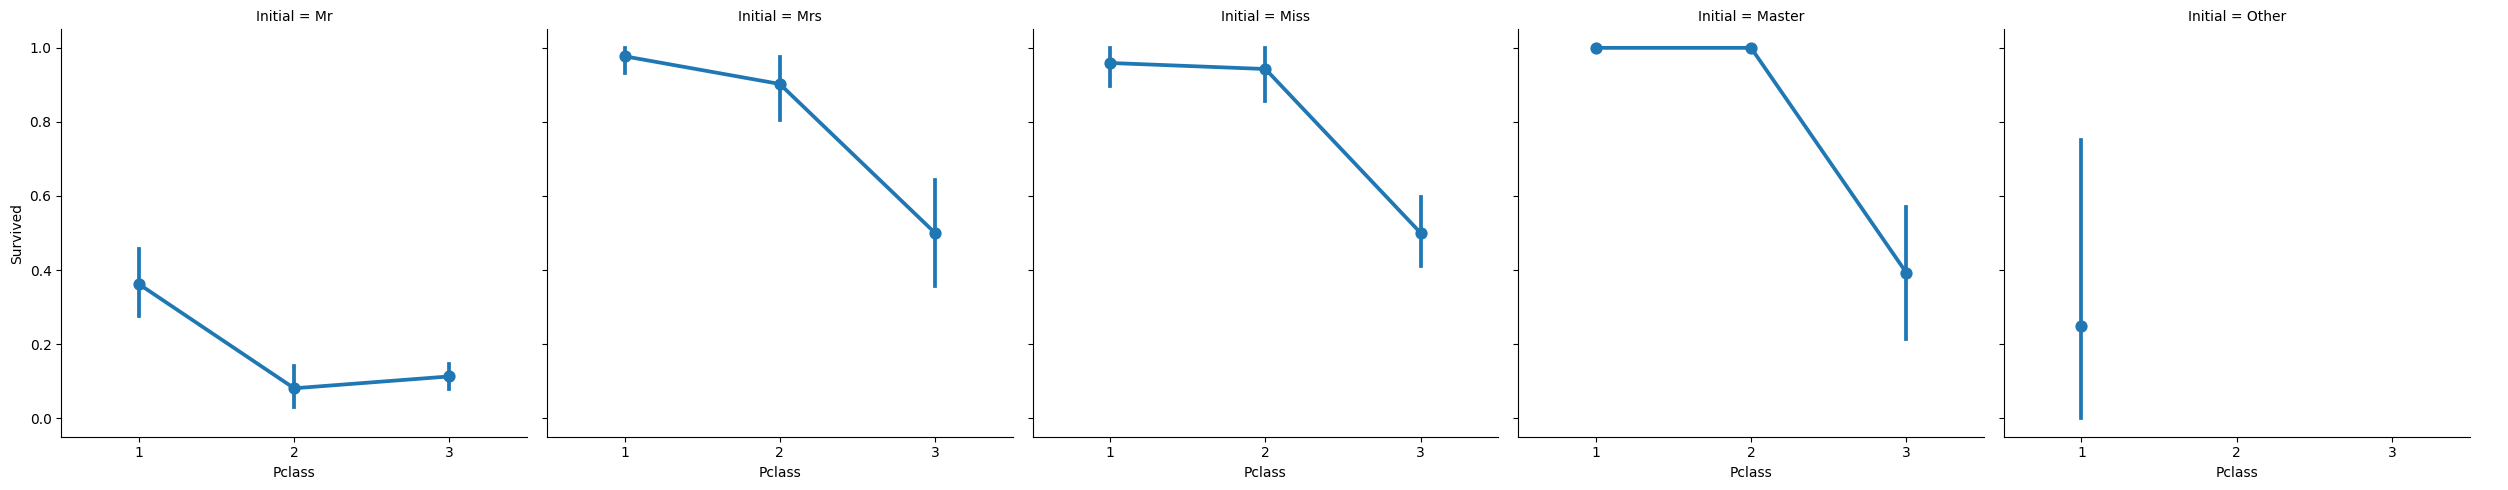

In [195]:
plt.figure(figsize=(20, 100))
sns.catplot(x='Pclass', y='Survived', col='Initial', data=train_data, kind='point')
plt.show()

# Feature: SibSp

In [197]:
pd.crosstab([train_data.SibSp], train_data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


c:\Users\gajen\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:2761: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try pointplot
  warnings.warn(msg, UserWarning)


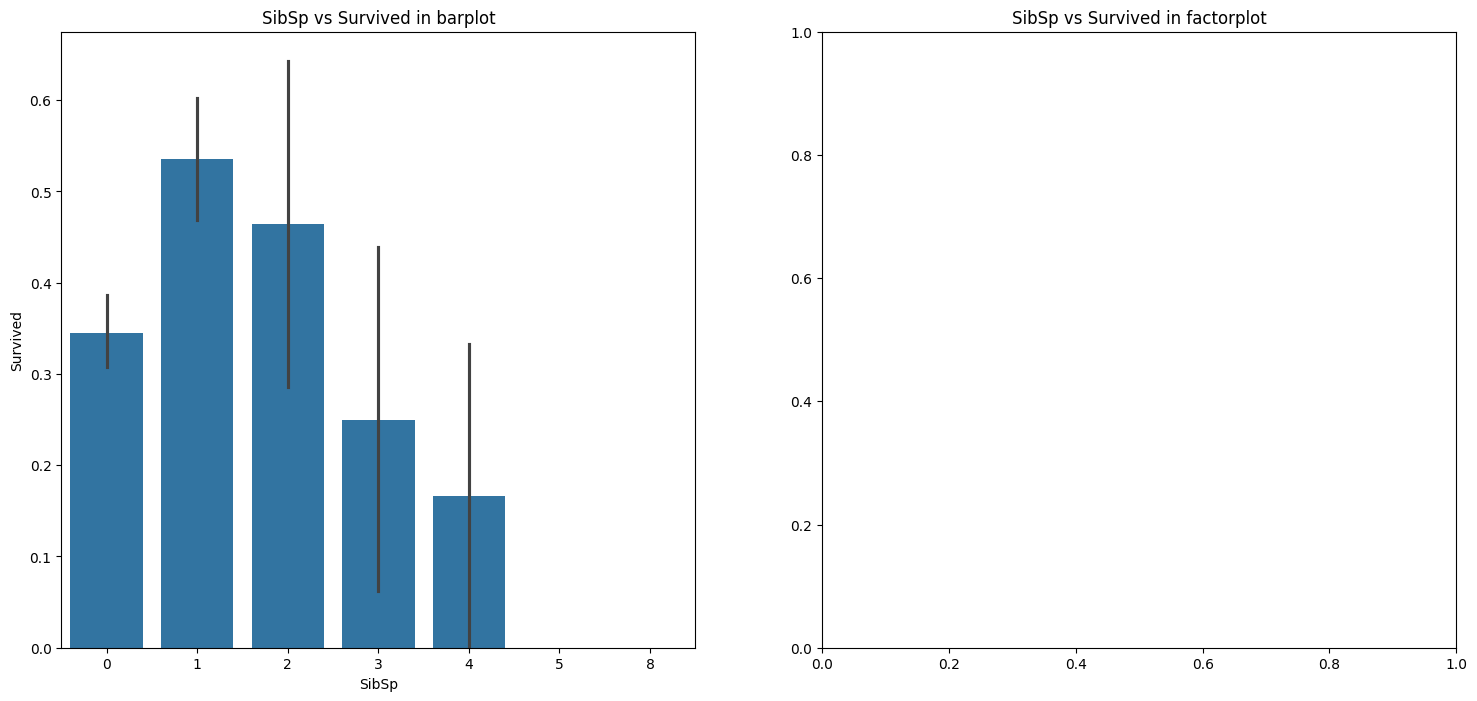

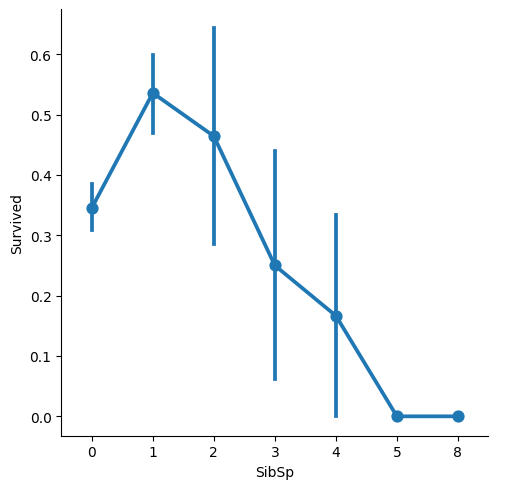

In [200]:
f, ax = plt.subplots(1,2,figsize=(18, 8))
sns.barplot(x='SibSp', y='Survived',data=train_data,ax=ax[0])
ax[0].set_title('SibSp vs Survived in barplot')
sns.catplot(x='SibSp', y='Survived',data=train_data, kind='point', ax=ax[1])
ax[1].set_title('SibSp vs Survived in factorplot')
plt.show()

In [203]:
pd.crosstab(train_data.SibSp,train_data.Pclass).style.background_gradient(cmap='summer')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


c:\Users\gajen\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:2761: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try pointplot
  warnings.warn(msg, UserWarning)


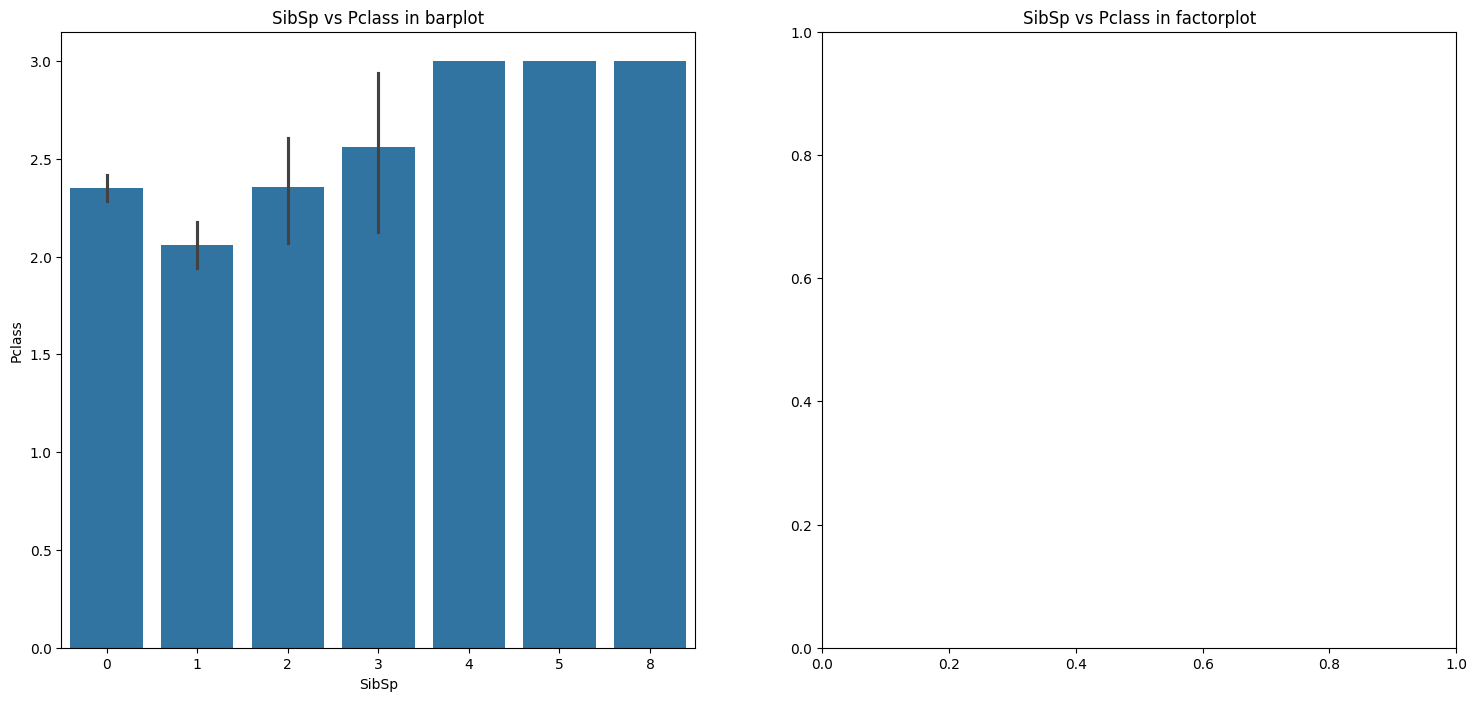

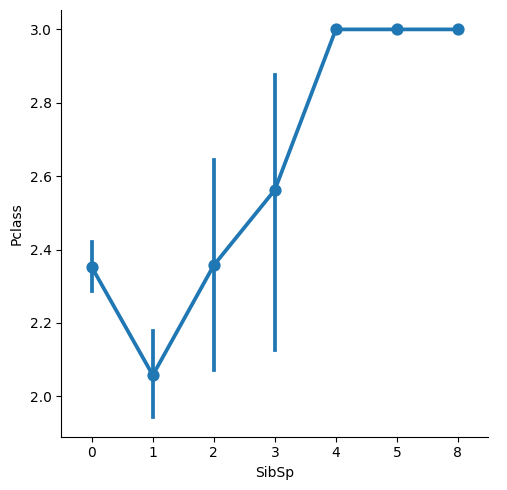

In [204]:
f, ax = plt.subplots(1,2,figsize=(18, 8))
sns.barplot(x='SibSp', y='Pclass',data=train_data,ax=ax[0])
ax[0].set_title('SibSp vs Pclass in barplot')
sns.catplot(x='SibSp', y='Pclass',data=train_data, kind='point', ax=ax[1])
ax[1].set_title('SibSp vs Pclass in factorplot')
plt.show()